# Importations

In [1]:
import pandas as pd
import numpy as np

from gensim.models import FastText

from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import LinearSVC

from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from imblearn.pipeline import Pipeline

from imblearn.under_sampling import RandomUnderSampler

from imblearn.over_sampling import SMOTE

from scipy.stats import uniform

import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# importer dataset

In [2]:
df = pd.read_csv("../data/raw/HateSpeechData.csv")

# Data Split

In [3]:
from sklearn.model_selection import train_test_split

y=df["class"]
X=df.drop(columns=["class"])

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [4]:
X_train_raw = X_train["tweet"]
X_test_raw = X_test["tweet"]

# Preprocessing

## 1. text cleaning

In [5]:
import re
import emoji
import contractions

# =========================
# Slang / abbreviation map
# =========================
SLANG_MAP = {
    "kys": "kill yourself",
    "stfu": "shut the fuck up",
    "wtf": "what the fuck",
    "idk": "i do not know",
    "imo": "in my opinion",
    "lmao": "laughing",
    "lol": "laughing",
    "u": "you",
    "ur": "your",
    "btw": "by the way",
    "omg": "oh my god",
    "fr": "for real",
    "ngl": "not gonna lie"
}


# =========================
# Expand slang words
# =========================
def expand_slang(text):

    words = text.split()

    expanded_words = [
        SLANG_MAP.get(word, word)
        for word in words
    ]

    return " ".join(expanded_words)


# =========================
# Normalize repeated chars
# loooool -> loool
# =========================
def normalize_repeated_chars(text):

    return re.sub(r"(.)\1{2,}", r"\1\1", text)


# =========================
# Main cleaning function
# =========================
def clean_text(text):

    # Vérifie si l'entrée est une chaîne de caractères
    if not isinstance(text, str):
        text = str(text)

    # Si le texte est vide
    if not text:
        return text

    # =========================
    # Emojis -> texte
    # 😊 -> smiling_face
    # =========================
    text = emoji.demojize(text)

    # =========================
    # Lowercase
    # =========================
    text = text.lower()

    # =========================
    # Remove URLs
    # =========================
    text = re.sub(r"http\S+|www\S+", " ", text)

    # =========================
    # Remove HTML entities
    # =========================
    text = re.sub(r"&amp;", " and ", text)
    text = re.sub(r"&lt;|&gt;", " ", text)

    # =========================
    # Remove RT (retweets)
    # =========================
    text = re.sub(r"\brt\b", " ", text)

    # =========================
    # Remove usernames
    # @user -> ""
    # =========================
    text = re.sub(r"@\w+", " ", text)

    # =========================
    # Hashtags
    # #StopHate -> StopHate
    # =========================
    text = re.sub(r"#(\w+)", r"\1", text)

    # =========================
    # Expand contractions
    # don't -> do not
    # =========================
    text = contractions.fix(text)

    # =========================
    # Expand slang
    # =========================
    text = expand_slang(text)

    # =========================
    # Normalize repeated chars
    # =========================
    text = normalize_repeated_chars(text)

    # =========================
    # Replace hyphens
    # =========================
    text = text.replace("-", " ")

    # =========================
    # Remove punctuation
    # Keep only letters/numbers/spaces
    # =========================
    text = re.sub(r"[^\w\s]", "", text)

    # =========================
    # Remove extra spaces
    # =========================
    text = re.sub(r"\s+", " ", text).strip()

    return text

## 2. tokenization

In [6]:
def tokenize_text(text):
    tokens = text.split()
    return tokens

## 3. Stopwrod 

In [7]:
import nltk
nltk.download('stopwords', quiet=True)

from nltk.corpus import stopwords

# Original stopwords
stop_words = set(stopwords.words('english'))

# Negation words to KEEP
negations = {
    "no",
    "nor",
    "not",
    "never",
    "n't"
}

# Remove negations from stopwords
stop_words = stop_words - negations


def remove_stopwords(tokens):
    return [w for w in tokens if w not in stop_words]

## 4. Lemmatization

In [8]:
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ZINEB\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ZINEB\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [9]:
def lemmatize_text(tokens):
    return [lemmatizer.lemmatize(w, pos='v') for w in tokens]

## 5. Preprocessing Functon

In [10]:
def full_preprocess(text):

    if pd.isna(text):
        return ""

    text = clean_text(text)

    tokens = tokenize_text(text)

    tokens = remove_stopwords(tokens)

    tokens = lemmatize_text(tokens)

    return " ".join(tokens)

# Transformer preprocessing

In [11]:
class TextPreprocessor(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        return X.apply(full_preprocess)

# Transformer TF-IDF + FastText

In [12]:
class TfidfFastTextVectorizer(
    BaseEstimator,
    TransformerMixin
):

    def __init__(
        self,
        vector_size=100,
        window=5,
        min_count=2,
        epochs=5
    ):

        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.epochs = epochs

    def fit(self, X, y=None):

        sentences = [
            text.split()
            for text in X.astype(str)
            if text.strip()
        ]

        # Train FastText
        self.fasttext_model = FastText(
            sentences=sentences,
            vector_size=self.vector_size,
            window=self.window,
            min_count=self.min_count,
            epochs=self.epochs
        )

        # TF-IDF
        self.tfidf = TfidfVectorizer()

        self.tfidf.fit(X)

        # IDF Dictionary
        self.idf_dict = dict(zip(
            self.tfidf.get_feature_names_out(),
            self.tfidf.idf_
        ))

        return self

    def transform(self, X):

        vectors = []

        for text in X.astype(str):

            tokens = text.split()

            weighted_vectors = []

            weights = []

            for word in tokens:

                if word in self.fasttext_model.wv:

                    weight = self.idf_dict.get(
                        word,
                        1.0
                    )

                    vector = self.fasttext_model.wv[word]

                    weighted_vectors.append(
                        vector * weight
                    )

                    weights.append(weight)

            if len(weighted_vectors) == 0:

                vectors.append(
                    np.zeros(self.vector_size)
                )

            else:

                vectors.append(
                    np.sum(
                        weighted_vectors,
                        axis=0
                    ) / np.sum(weights)
                )

        return np.array(vectors)

<div style="
    background: linear-gradient(135deg, #1f4037, #99f2c8);
    padding: 20px;
    border-radius: 12px;
    text-align: center;
    box-shadow: 0 4px 12px rgba(0,0,0,0.2);
    margin-bottom: 20px;
">
    <h1 style="
        color: white;
        font-family: 'Arial', sans-serif;
        margin: 0;
        font-size: 42px;
        letter-spacing: 1px;
    ">
        Pipeline complèt "SVM"
    </h1>
</div>

In [13]:
pipeline = Pipeline([

    (
        'preprocess',
        TextPreprocessor()
    ),

    (
        'vectorizer',
        TfidfFastTextVectorizer()
    ),

    (
        'under',
        RandomUnderSampler(
            sampling_strategy={
                1: 5000
            },
            random_state=42
        )
    ),

    (
        'smote',
        SMOTE(
            sampling_strategy={
                0: 5000,
                2: 5000
            },
            random_state=42
        )
    ),

    (
        'svm',
        LinearSVC(
            random_state=42
        )
    )
])

# Hyperparametres

In [14]:
param_dist = {

    'svm__C': uniform(
        0.01,
        100
    ),

    'svm__loss': [
        'hinge',
        'squared_hinge'
    ],

    'svm__max_iter': [
        3000,
        5000,
        10000
    ]
}

# Cross Validarion

In [15]:
cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)

# Random Search

In [16]:
random_search = RandomizedSearchCV(

    estimator=pipeline,

    param_distributions=param_dist,

    n_iter=10,

    scoring='f1_macro',

    cv=cv,

    verbose=2,

    n_jobs=-1,

    random_state=42
)

# Entrainement

In [17]:
random_search.fit(
    X_train_raw,
    y_train
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\ZINEB\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'svm__C': <scipy.stats....00200B3C96800>, 'svm__loss': ['hinge', 'squared_hinge'], 'svm__max_iter': [3000, 5000, ...]}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


# Meilleurs parametres

In [18]:
print("Best Parameters:")

print(random_search.best_params_)

print("\nBest CV Score:")

print(random_search.best_score_)

Best Parameters:
{'svm__C': 73.20939418114051, 'svm__loss': 'hinge', 'svm__max_iter': 3000}

Best CV Score:
0.5982066159031363


# Meilleur Modele

In [19]:
best_model = random_search.best_estimator_

# Prédictions TEST

In [20]:
y_pred = best_model.predict(
    X_test_raw
)

# Metriques

In [25]:
import pandas as pd
from sklearn.metrics import classification_report

# Predictions
y_train_pred = best_model.predict(X_train_raw)
y_test_pred = best_model.predict(X_test_raw)

# Reports par classe
train_report = classification_report(
    y_train,
    y_train_pred,
    output_dict=True
)

test_report = classification_report(
    y_test,
    y_test_pred,
    output_dict=True
)

# Convert to DataFrame
train_df = pd.DataFrame(train_report).transpose()
test_df = pd.DataFrame(test_report).transpose()

# Keep only classes (remove accuracy/avg rows)
classes = [str(c) for c in sorted(y_train.unique())]

train_classes = train_df.loc[classes, ["precision", "recall", "f1-score"]]
test_classes = test_df.loc[classes, ["precision", "recall", "f1-score"]]

# Rename columns
train_classes.columns = pd.MultiIndex.from_product([["Train"], train_classes.columns])
test_classes.columns = pd.MultiIndex.from_product([["Test"], test_classes.columns])

# Combine side by side
final_df = pd.concat([train_classes, test_classes], axis=1)

final_df

Train                          Test                    
  precision    recall  f1-score precision    recall  f1-score
0  0.175246  0.529720  0.263364  0.172654  0.520979  0.259356
1  0.962413  0.697173  0.808597  0.951134  0.710005  0.813069
2  0.560701  0.883483  0.686021  0.570382  0.841537  0.679922

# Matrice de confusion

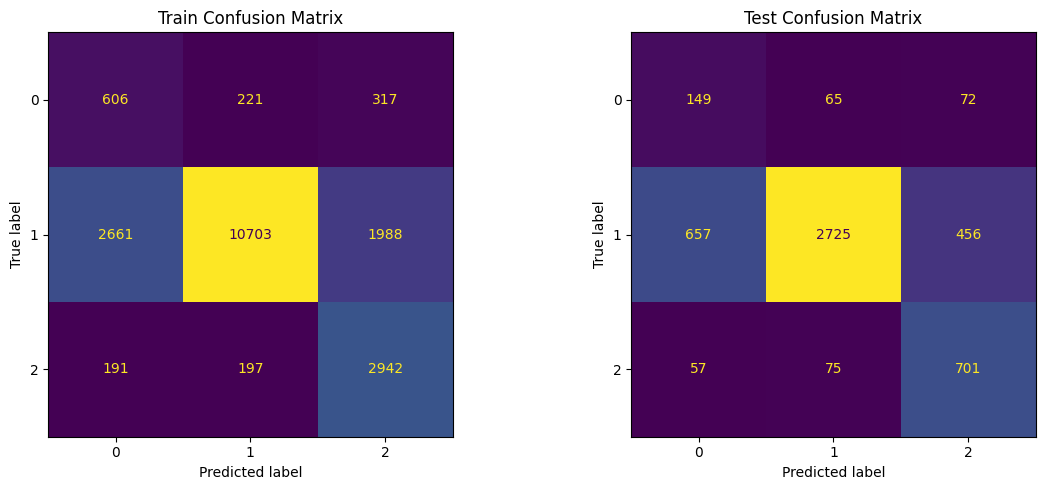

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_train_pred = best_model.predict(X_train_raw)
y_test_pred = best_model.predict(X_test_raw)

# Confusion matrices
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

# Plot side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_train).plot(ax=ax[0], colorbar=False)
ax[0].set_title("Train Confusion Matrix")

ConfusionMatrixDisplay(cm_test).plot(ax=ax[1], colorbar=False)
ax[1].set_title("Test Confusion Matrix")

plt.tight_layout()
plt.show()

<div style="
    background: linear-gradient(135deg, #1f4037, #99f2c8);
    padding: 20px;
    border-radius: 12px;
    text-align: center;
    box-shadow: 0 4px 12px rgba(0,0,0,0.2);
    margin-bottom: 20px;
">
    <h1 style="
        color: white;
        font-family: 'Arial', sans-serif;
        margin: 0;
        font-size: 42px;
        letter-spacing: 1px;
    ">
        Pipeline complèt "RL"
    </h1>
</div>

In [26]:
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([

    ('preprocess', TextPreprocessor()),

    ('vectorizer', TfidfFastTextVectorizer()),

    ('under', RandomUnderSampler(
        sampling_strategy={1: 5000},
        random_state=42
    )),

    ('smote', SMOTE(
        sampling_strategy={0: 5000, 2: 5000},
        random_state=42
    )),

    ('clf', LogisticRegression(
        random_state=42,
        max_iter=2000
    ))
])

# Hyperparametre

In [27]:
from scipy.stats import uniform

param_dist = {

    'clf__C': uniform(0.01, 100),

    'clf__penalty': ['l2'],

    'clf__solver': ['lbfgs', 'saga'],

    'clf__max_iter': [1000, 2000, 5000]
}

# Cross validation

In [28]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Random Search

In [29]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(

    estimator=pipeline,

    param_distributions=param_dist,

    n_iter=10,

    scoring='f1_macro',

    cv=cv,

    verbose=2,

    n_jobs=-1,

    random_state=42
)

# Entrainement

In [30]:
random_search.fit(
    X_train_raw,
    y_train
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\ZINEB\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'clf__C': <scipy.stats....00200BB2456F0>, 'clf__max_iter': [1000, 2000, ...], 'clf__penalty': ['l2'], 'clf__solver': ['lbfgs', 'saga']}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


# Best Model

In [31]:
best_model = random_search.best_estimator_

print(random_search.best_params_)
print(random_search.best_score_)

{'clf__C': 61.195289472237945, 'clf__max_iter': 2000, 'clf__penalty': 'l2', 'clf__solver': 'saga'}
0.552103539244083


# Presictions

In [32]:
y_pred = best_model.predict(X_test_raw)

# Metriques globale

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.15      0.53      0.23       286
           1       0.95      0.68      0.79      3838
           2       0.58      0.82      0.68       833

    accuracy                           0.69      4957
   macro avg       0.56      0.68      0.57      4957
weighted avg       0.84      0.69      0.74      4957



# Metrique train vs test

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

y_train_pred = best_model.predict(X_train_raw)
y_test_pred = best_model.predict(X_test_raw)

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='macro'),
        "Recall": recall_score(y_true, y_pred, average='macro'),
        "F1-score": f1_score(y_true, y_pred, average='macro')
    }

metrics_df = pd.DataFrame({
    "Train": get_metrics(y_train, y_train_pred),
    "Test": get_metrics(y_test, y_test_pred)
})

metrics_df

,Train,Test
Accuracy,0.695400,0.692153
Precision,0.558896,0.557280
Recall,0.685442,0.677635
F1-score,0.569223,0.566303


# Matrice de Confusion


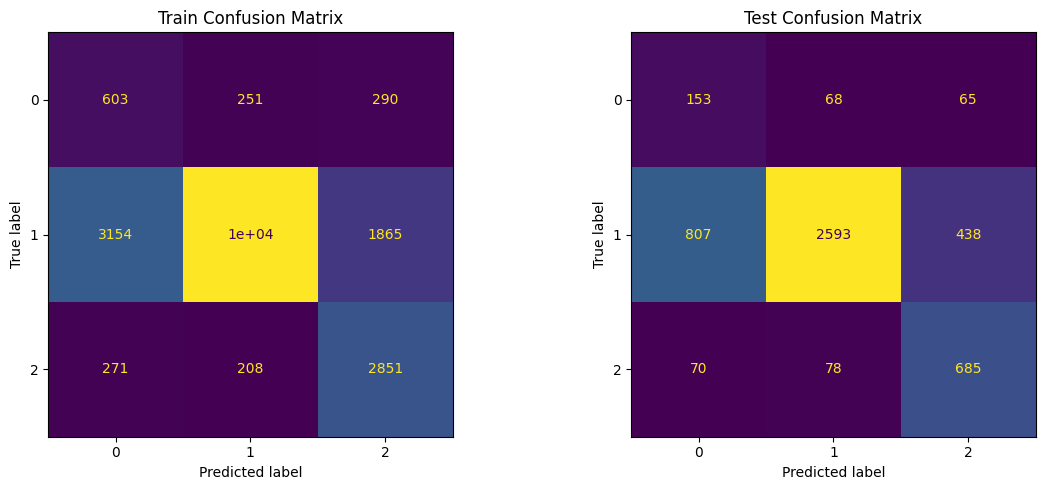

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_train).plot(ax=ax[0], colorbar=False)
ax[0].set_title("Train Confusion Matrix")

ConfusionMatrixDisplay(cm_test).plot(ax=ax[1], colorbar=False)
ax[1].set_title("Test Confusion Matrix")

plt.tight_layout()
plt.show()

<div style="
    background: linear-gradient(135deg, #1f4037, #99f2c8);
    padding: 20px;
    border-radius: 12px;
    text-align: center;
    box-shadow: 0 4px 12px rgba(0,0,0,0.2);
    margin-bottom: 20px;
">
    <h1 style="
        color: white;
        font-family: 'Arial', sans-serif;
        margin: 0;
        font-size: 42px;
        letter-spacing: 1px;
    ">
        Pipeline complèt "Stacking"
    </h1>
</div>

In [37]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Base models
base_models = [
    ('lr', LogisticRegression(
        max_iter=2000,
        random_state=42
    )),

    ('svm', LinearSVC(
        random_state=42
    ))
]

# Meta model
meta_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    passthrough=False,   # True = ajoute features originales au meta-model
    cv=5,
    n_jobs=-1
)

In [38]:
pipeline = Pipeline([

    ('preprocess', TextPreprocessor()),

    ('vectorizer', TfidfFastTextVectorizer()),

    ('under', RandomUnderSampler(
        sampling_strategy={1: 5000},
        random_state=42
    )),

    ('smote', SMOTE(
        sampling_strategy={0: 5000, 2: 5000},
        random_state=42
    )),

    ('clf', stacking_model)
])

# Hyperparametres

In [39]:
param_dist = {

    'clf__final_estimator__C': uniform(0.01, 10),

    'clf__passthrough': [True, False]
}

# Cross Validation

In [41]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Rnadom Search

In [42]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(

    estimator=pipeline,

    param_distributions=param_dist,

    n_iter=5,   # stacking = lourd → petit n_iter

    scoring='f1_macro',

    cv=cv,

    verbose=2,

    n_jobs=-1,

    random_state=42
)

# Training

In [44]:
random_search.fit(
    X_train_raw,
    y_train
)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,estimator,Pipeline(step... n_jobs=-1))])
,param_distributions,"{'clf__final_estimator__C': <scipy.stats....00200BB1C2C20>, 'clf__passthrough': [True, False]}"
,n_iter,5
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


# Best Model

In [45]:
best_model = random_search.best_estimator_

print(random_search.best_params_)
print(random_search.best_score_)

{'clf__final_estimator__C': 4.468327528535911, 'clf__passthrough': True}
0.5376527919318724


# TEST predictions

In [46]:
y_pred = best_model.predict(X_test_raw)

# Metrics globales

In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.15      0.51      0.23       286
           1       0.93      0.68      0.79      3838
           2       0.54      0.77      0.64       833

    accuracy                           0.68      4957
   macro avg       0.54      0.65      0.55      4957
weighted avg       0.82      0.68      0.73      4957



# Train vs Test metrics

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

y_train_pred = best_model.predict(X_train_raw)
y_test_pred = best_model.predict(X_test_raw)

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='macro'),
        "Recall": recall_score(y_true, y_pred, average='macro'),
        "F1-score": f1_score(y_true, y_pred, average='macro')
    }

metrics_df = pd.DataFrame({
    "Train": get_metrics(y_train, y_train_pred),
    "Test": get_metrics(y_test, y_test_pred)
})

metrics_df

,Train,Test
Accuracy,0.694744,0.684890
Precision,0.551717,0.541361
Recall,0.682677,0.652546
F1-score,0.565939,0.550863


# Confusion Matrix (Train vs Test)

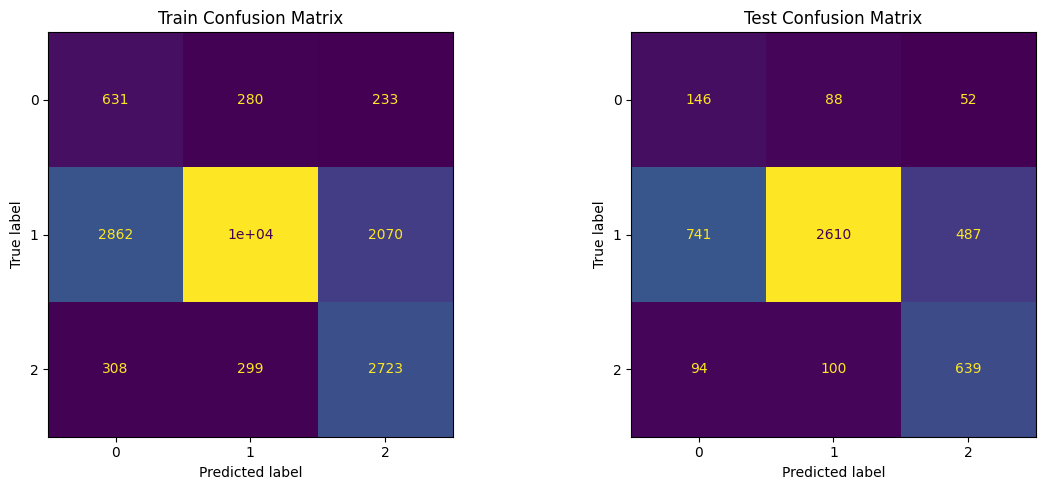

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_train).plot(ax=ax[0], colorbar=False)
ax[0].set_title("Train Confusion Matrix")

ConfusionMatrixDisplay(cm_test).plot(ax=ax[1], colorbar=False)
ax[1].set_title("Test Confusion Matrix")

plt.tight_layout()
plt.show()